N= 2, τ=0.6822, Eb=1.058141, Ergotropy=1.020168, erg/Eb=0.964113656811 Variance=5.7360123461e-01
N= 3, τ=0.5807, Eb=1.683140, Ergotropy=1.636665, erg/Eb=0.972388170775 Variance=8.8272451426e-01
N= 4, τ=0.5158, Eb=2.323216, Ergotropy=2.270698, erg/Eb=0.977394394329 Variance=1.1937538140e+00
N= 5, τ=0.4696, Eb=2.973274, Ergotropy=2.916091, erg/Eb=0.980767563475 Variance=1.5059273703e+00
N= 6, τ=0.4344, Eb=3.629996, Ergotropy=3.569077, erg/Eb=0.983217933250 Variance=1.8187601912e+00
N= 7, τ=0.4065, Eb=4.292903, Ergotropy=4.228811, erg/Eb=0.985070193266 Variance=2.1321821520e+00
N= 8, τ=0.3835, Eb=4.959030, Ergotropy=4.892298, erg/Eb=0.986543292203 Variance=2.4458195083e+00
N= 9, τ=0.3642, Eb=5.629110, Ergotropy=5.560055, erg/Eb=0.987732652270 Variance=2.7597666724e+00
N=10, τ=0.3478, Eb=6.304396, Ergotropy=6.233174, erg/Eb=0.988702715969 Variance=3.0741375689e+00
N=11, τ=0.3334, Eb=6.979895, Ergotropy=6.906858, erg/Eb=0.989536086788 Variance=3.3884156286e+00
N=12, τ=0.3208, Eb=7.659301, E

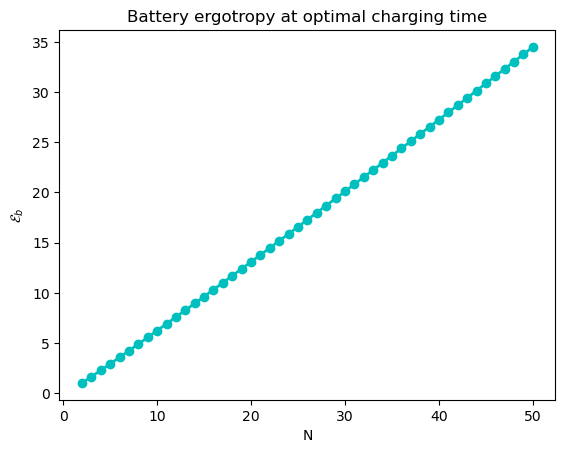

In [3]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 51, 1)
nmax = 80
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, N)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ])
    
    rho_b = res.states[-1].ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()
        
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]

    # assign degenerate energies 
    e_vals = np.array([0] + [ω0]*N)
    
    # e_vals = np.arange(N + 1) * ω0
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = E_B - sum(r_vals[j]*e_vals[j] for j in range(len(r_vals)))

    W_2 = (qt.expect(HB**2, rho_b) + sum(r_vals[j]*(e_vals[j])**2 for j in range(len(r_vals)))) - 2 * sum(e_vals[i]*r_vals[i]*qt.expect(HB, r_vecs[i]) for i in range(len(r_vals)))
    
    ΔE2 = W_2 - (E_erg)**2
    
    ΔE = np.sqrt(ΔE2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)


    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.savefig("OP1")
plt.show()

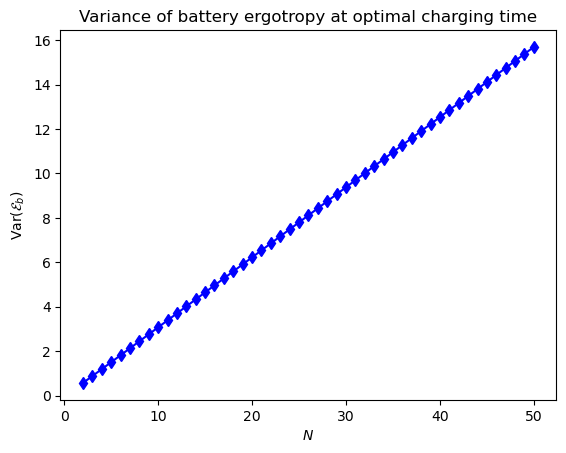

In [4]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.savefig("OP2")
plt.show()

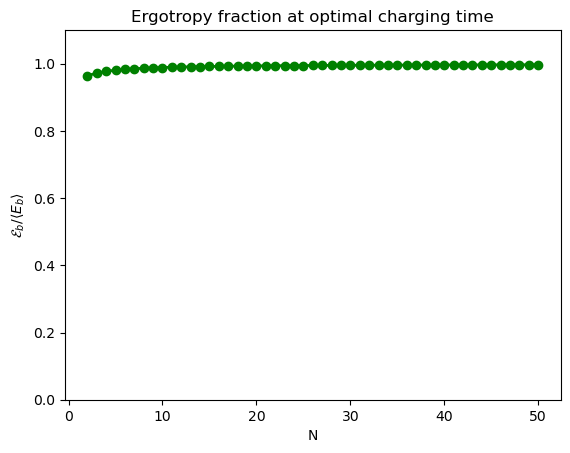

In [5]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.savefig("OP3")
plt.show()

N= 2, τ=0.6822, Relative Fluctuation =0.742391861029, Relative Fluctuation with Eb =0.715750131923
N= 3, τ=0.5807, Relative Fluctuation =0.574053949080, Relative Fluctuation with Eb =0.558203269472
N= 4, τ=0.5158, Relative Fluctuation =0.481169330014, Relative Fluctuation with Eb =0.470292205879
N= 5, τ=0.4696, Relative Fluctuation =0.420824418140, Relative Fluctuation with Eb =0.412730939230
N= 6, τ=0.4344, Relative Fluctuation =0.377860783958, Relative Fluctuation with Eb =0.371519499059
N= 7, τ=0.4065, Relative Fluctuation =0.345297839188, Relative Fluctuation with Eb =0.340142609184
N= 8, τ=0.3835, Relative Fluctuation =0.319668083012, Relative Fluctuation with Eb =0.315366403027
N= 9, τ=0.3642, Relative Fluctuation =0.298783814548, Relative Fluctuation with Eb =0.295118529599
N=10, τ=0.3478, Relative Fluctuation =0.281288788783, Relative Fluctuation with Eb =0.278110989441
N=11, τ=0.3334, Relative Fluctuation =0.266512658437, Relative Fluctuation with Eb =0.263723893109
N=12, τ=0.

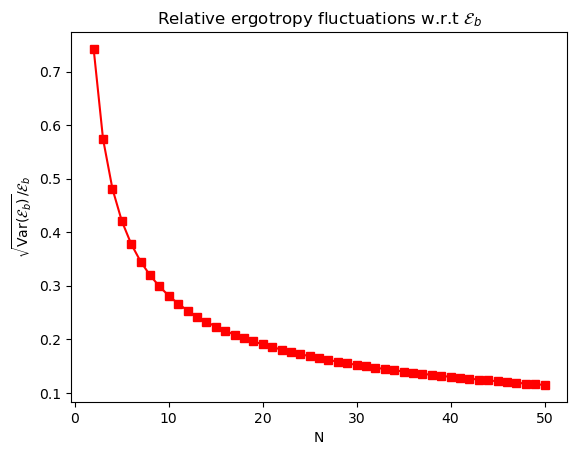

In [6]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.savefig("OP4")
plt.show()

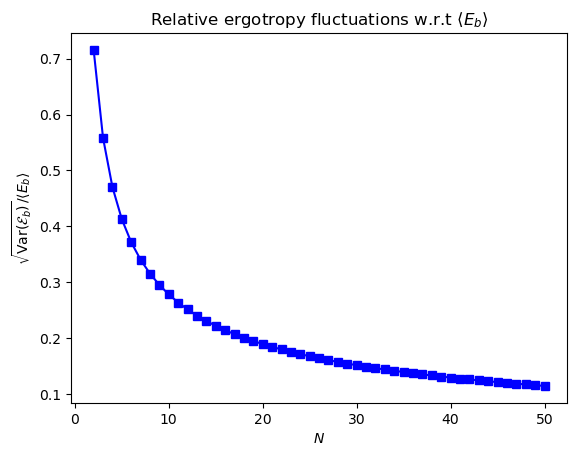

In [7]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.savefig("OP5")
plt.show()

Best fit parameters: A = -0.001411, B = 0.060213, Optimal value for alpha: 0.674064


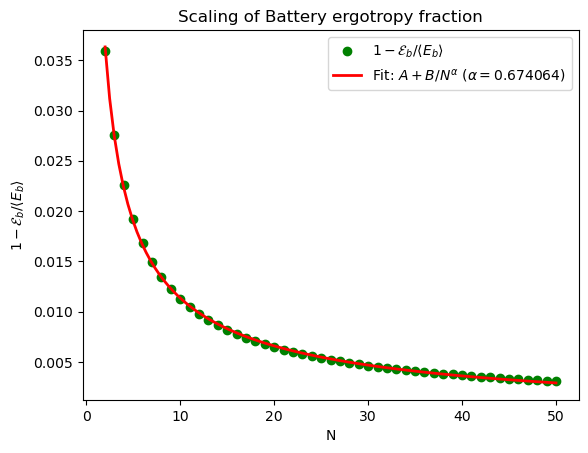

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# The fitting function
def asymptotic_fit(N, alpha, A, B):
    return (A + B / (N**alpha))


y_data = 1 - np.array(E_ratio) 

# The curve fit

popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
alpha_opt, A_opt, B_opt = popt

print(f"Best fit parameters: A = {A_opt:.6f}, B = {B_opt:.6f}, Optimal value for alpha: {alpha_opt:.6f}")

# A smooth curve for the fit using the optimal parameters

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, alpha_opt, A_opt, B_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='g', markersize=6, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A + B/N^{{\alpha}}$ ($\alpha={alpha_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Scaling of Battery ergotropy fraction")
plt.legend()
plt.savefig("OP6")
plt.show()

Optimal value for alpha: 0.548063


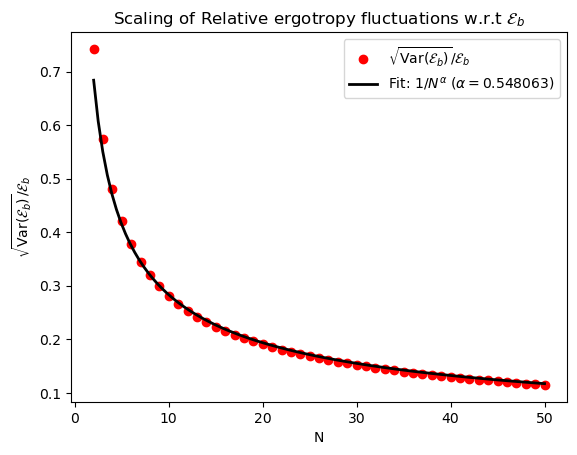

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function
def asymptotic_fit(N, alpha):
    return (1 / (N**alpha))

y_data = np.array(F_ratio) 

# The curve fit
popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
alpha_opt = popt[0]

print(f"Optimal value for alpha: {alpha_opt:.6f}")

# A smooth curve for the fit using the optimal alpha

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, alpha_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='r', markersize=6, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.plot(N_smooth, y_fit, '-', color='k', linewidth=2, label=rf'Fit: $1/N^{{\alpha}}$ ($\alpha={alpha_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.savefig("OP7")
plt.show()